In [616]:
##import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [617]:
#upload dataset
df = pd.read_csv("Housing.csv")


In [618]:
#view data 
df.head(3)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished


In [619]:
df.shape

(545, 13)

In [620]:
df.size

7085

In [621]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [622]:
df[df.duplicated()].shape

(0, 13)

In [623]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [624]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [625]:
df.skew(numeric_only=True)

price        1.212239
area         1.321188
bedrooms     0.495684
bathrooms    1.589264
stories      1.082088
parking      0.842062
dtype: float64

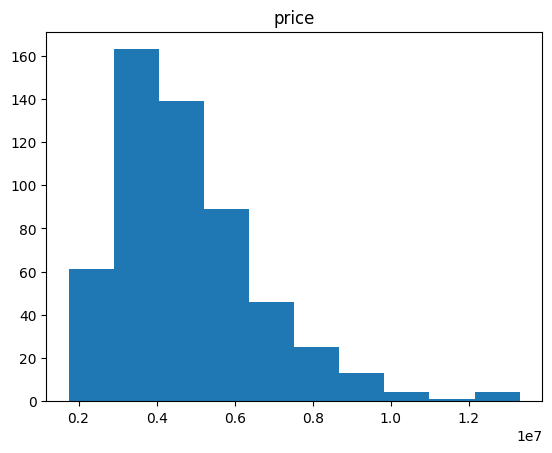

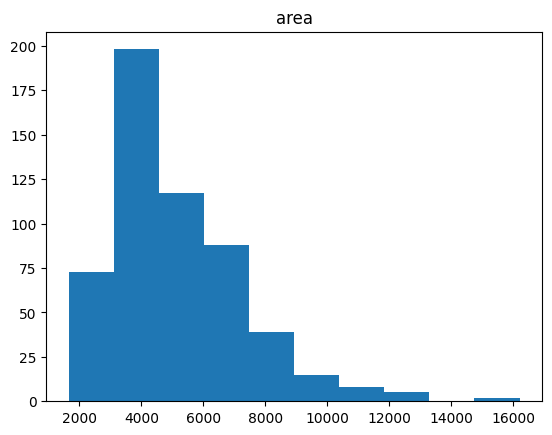

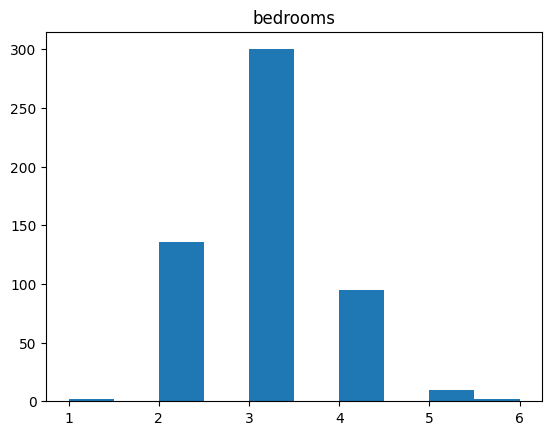

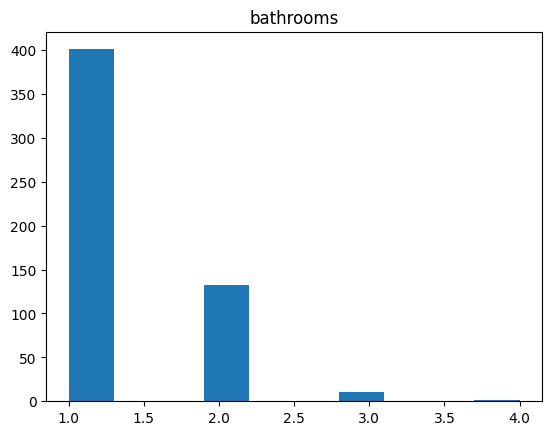

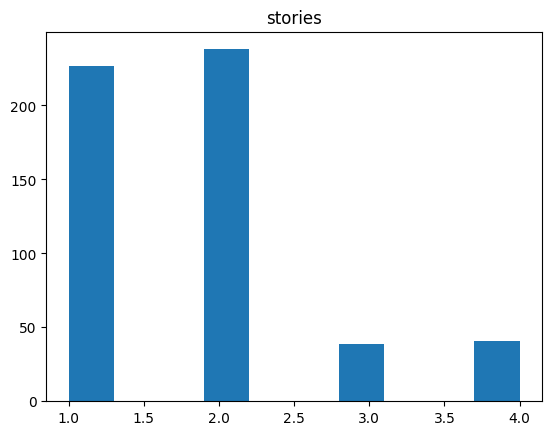

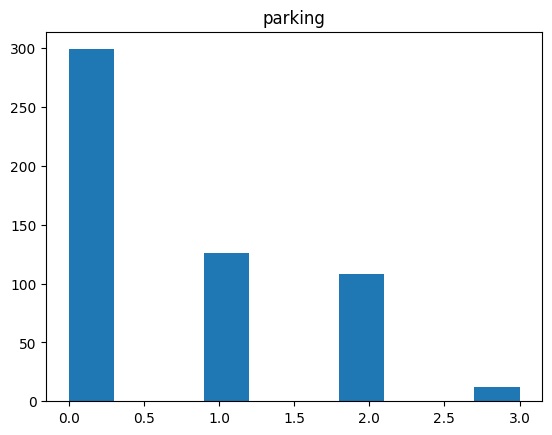

In [626]:
numeric_cols = ["price","area","bedrooms","bathrooms","stories","parking"]
for i in numeric_cols:
    plt.hist(df[i])
    plt.title(i)
    plt.show()

In [627]:
df.nunique()

price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64

In [628]:
for col in df.columns:
    if df[col].nunique() < 20:
        print(col)
        print(df[col].value_counts())
        print("-"*50)

bedrooms
bedrooms
3    300
2    136
4     95
5     10
6      2
1      2
Name: count, dtype: int64
--------------------------------------------------
bathrooms
bathrooms
1    401
2    133
3     10
4      1
Name: count, dtype: int64
--------------------------------------------------
stories
stories
2    238
1    227
4     41
3     39
Name: count, dtype: int64
--------------------------------------------------
mainroad
mainroad
yes    468
no      77
Name: count, dtype: int64
--------------------------------------------------
guestroom
guestroom
no     448
yes     97
Name: count, dtype: int64
--------------------------------------------------
basement
basement
no     354
yes    191
Name: count, dtype: int64
--------------------------------------------------
hotwaterheating
hotwaterheating
no     520
yes     25
Name: count, dtype: int64
--------------------------------------------------
airconditioning
airconditioning
no     373
yes    172
Name: count, dtype: int64
-------------------------

In [629]:
data_num = df.select_dtypes(include=np.number)
data_cat = df.select_dtypes(exclude=np.number)

In [630]:
data_num

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2
...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2
541,1767150,2400,3,1,1,0
542,1750000,3620,2,1,1,0
543,1750000,2910,3,1,1,0


In [631]:
data_cat

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,yes,no,yes,no,furnished
...,...,...,...,...,...,...,...
540,yes,no,yes,no,no,no,unfurnished
541,no,no,no,no,no,no,semi-furnished
542,yes,no,no,no,no,no,unfurnished
543,no,no,no,no,no,no,furnished


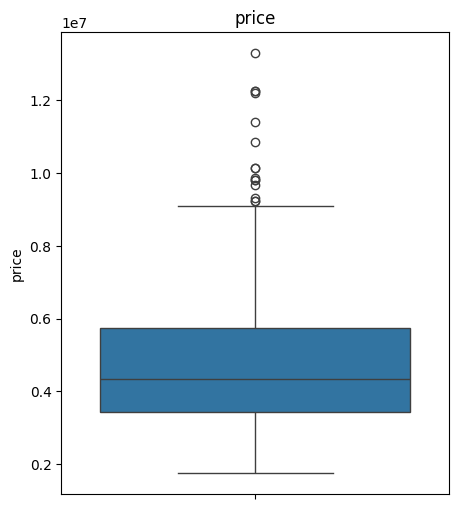

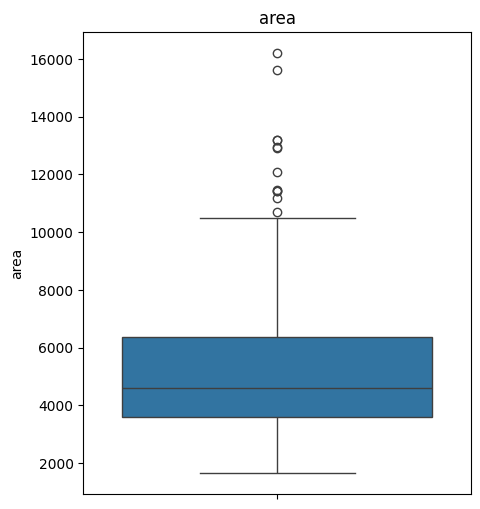

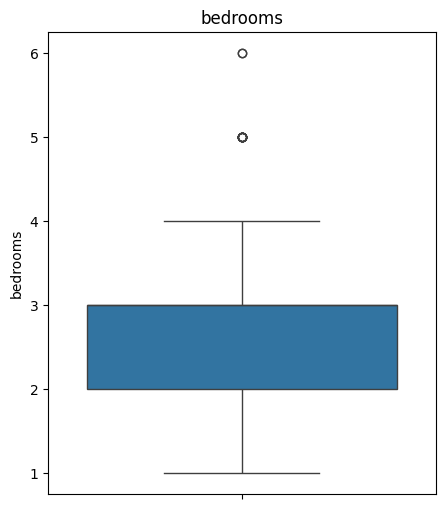

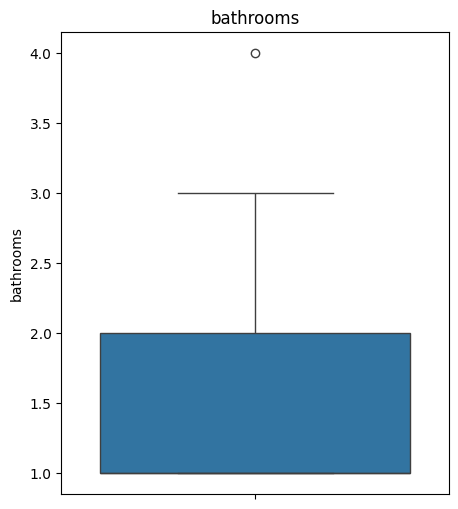

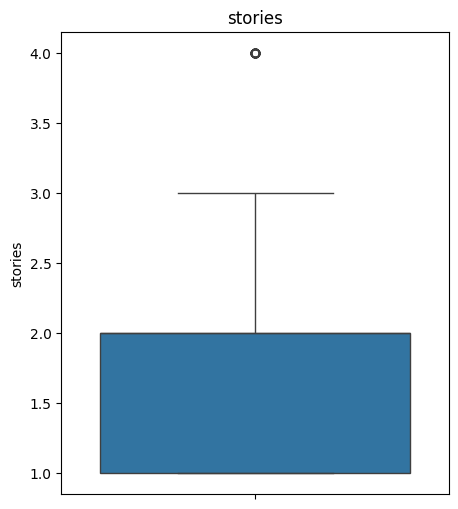

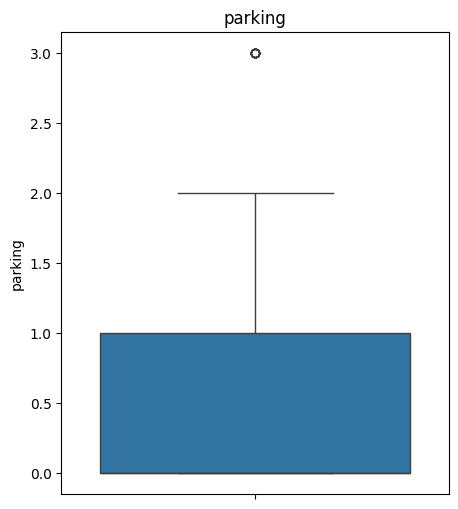

In [632]:
for i in data_num.columns:
    plt.figure(figsize=(5,6))
    sns.boxplot(data_num[i])
    plt.title(i)
    plt.show()

In [633]:
# cols = ["area","bedrooms","bathrooms","stories","parking"]
# original_shape = df.shape

# for col in cols:

#     q1 = df[col].quantile(0.25)
#     q3 = df[col].quantile(0.75)
    
#     iqr = q3-q1

#     lower = q1-1.5*iqr
#     upper = q3+1.5*iqr

#     df= df[(df[col]>=lower) & (df[col]<=upper)]

# print("Original shape:",original_shape)
# print("After Outlier Removal:",df.shape)

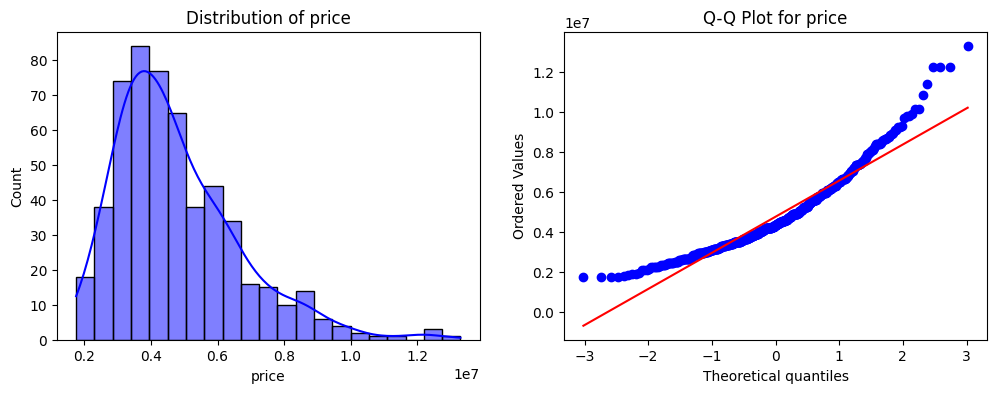

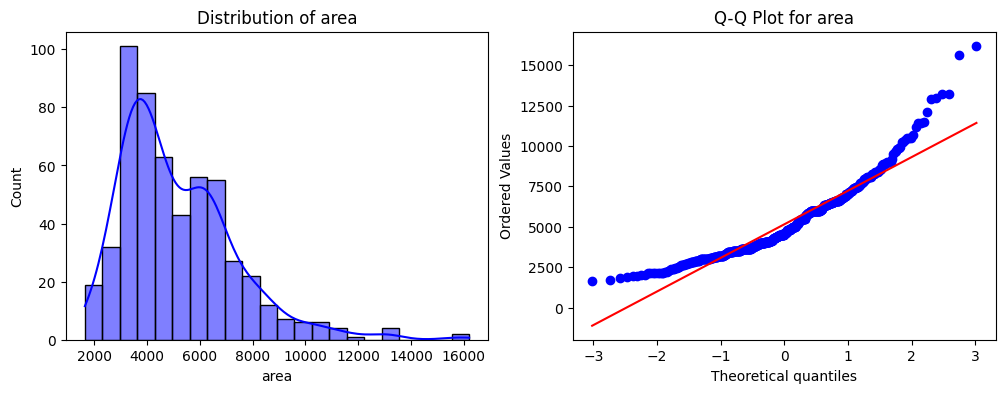

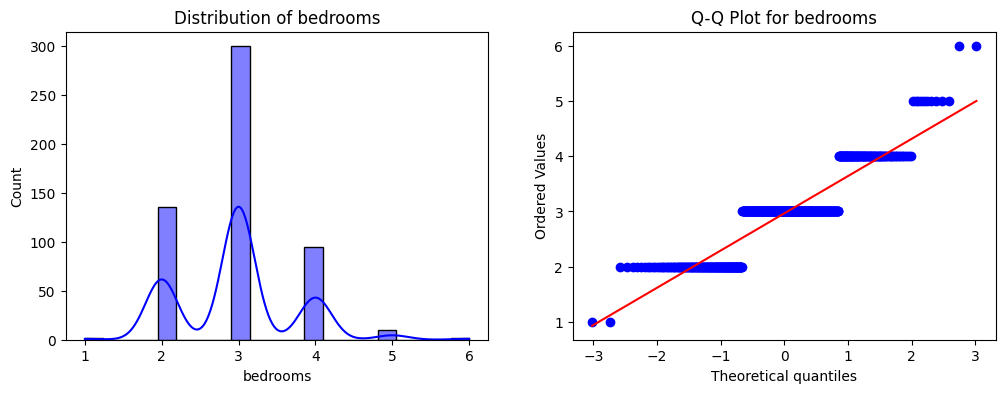

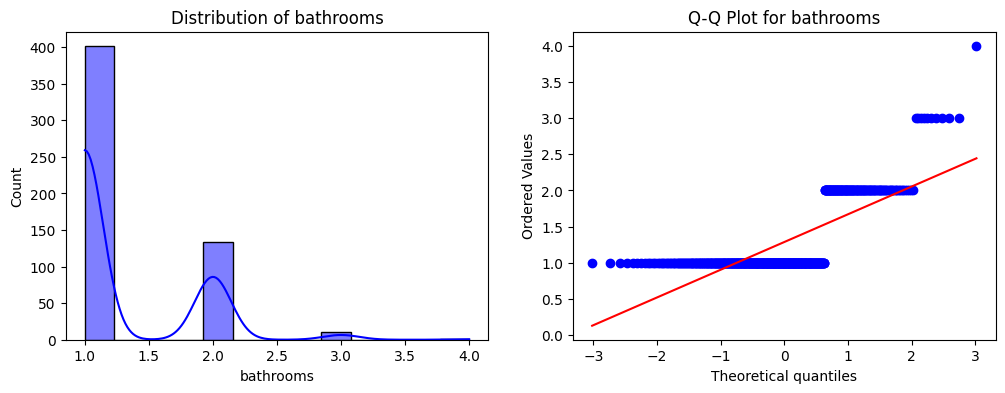

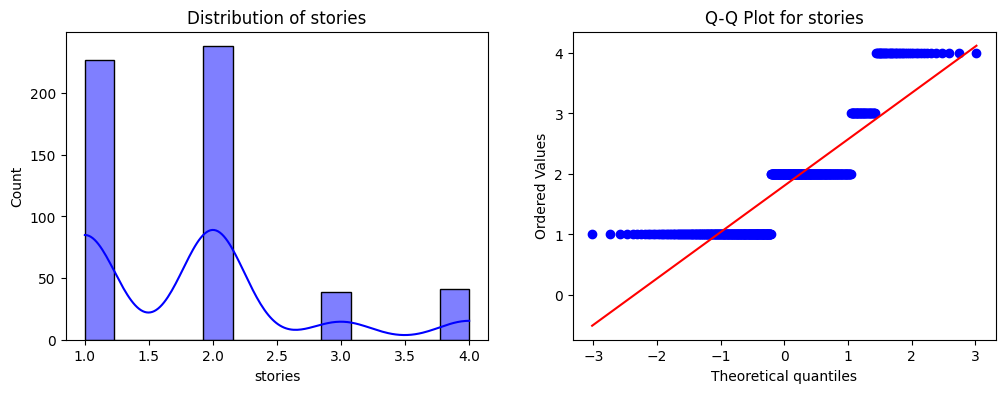

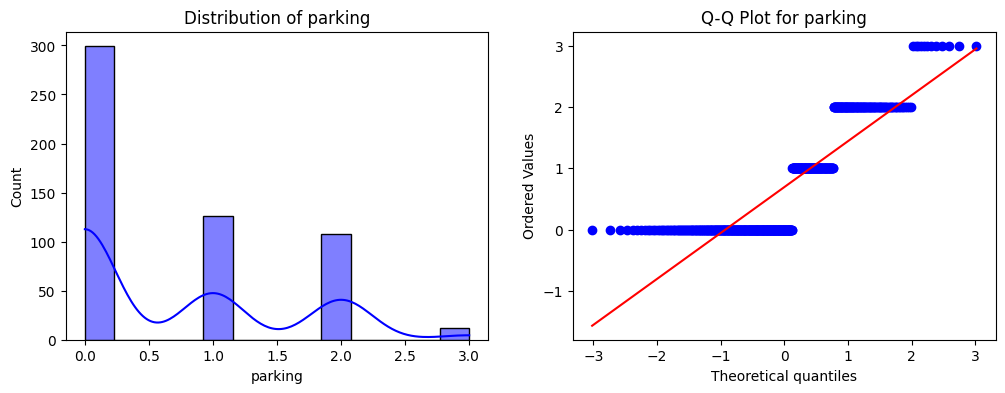

In [634]:
from scipy import stats
for col in numeric_cols:
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Distribution of {col}')
    
    plt.subplot(1, 2, 2)
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot for {col}')
    plt.show()


 Frequency counts for mainroad:
 mainroad
yes    468
no      77
Name: count, dtype: int64


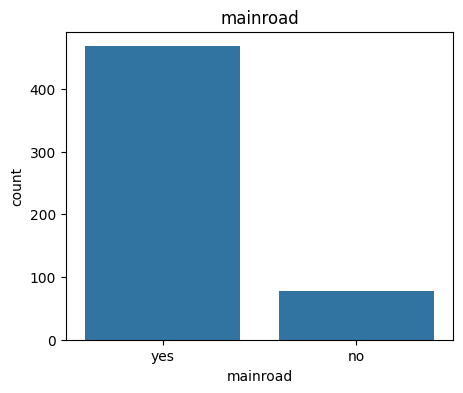


 Frequency counts for guestroom:
 guestroom
no     448
yes     97
Name: count, dtype: int64


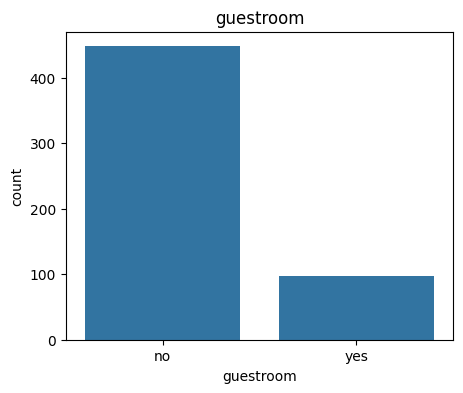


 Frequency counts for basement:
 basement
no     354
yes    191
Name: count, dtype: int64


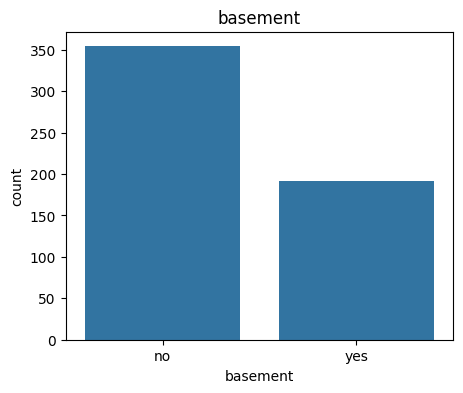


 Frequency counts for hotwaterheating:
 hotwaterheating
no     520
yes     25
Name: count, dtype: int64


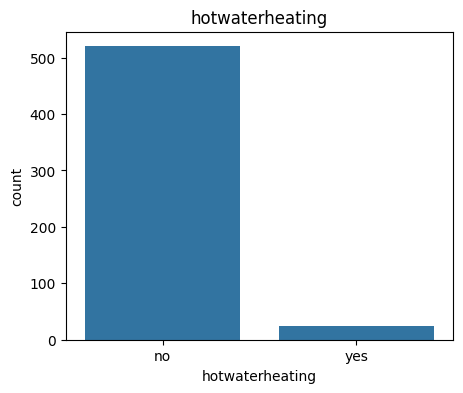


 Frequency counts for airconditioning:
 airconditioning
no     373
yes    172
Name: count, dtype: int64


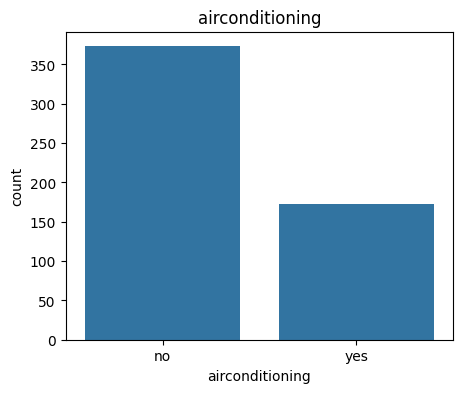


 Frequency counts for prefarea:
 prefarea
no     417
yes    128
Name: count, dtype: int64


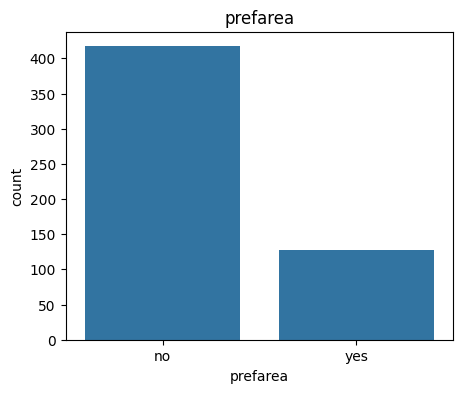


 Frequency counts for furnishingstatus:
 furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


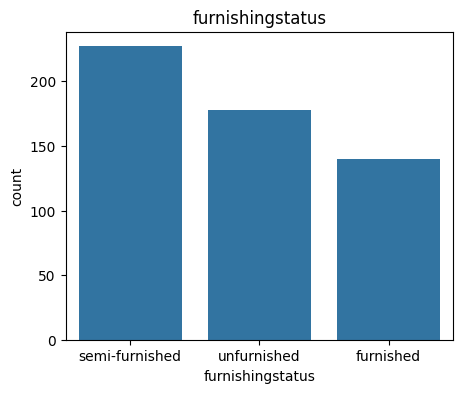

In [635]:
cat_cols = df.select_dtypes(include='object').columns

for index, col in enumerate(cat_cols):
    print(f"\n Frequency counts for {col}:\n", df[col].value_counts())
    plt.figure(figsize=(5,4))
    sns.countplot(x =col,data=df,order=df[col].value_counts().index)
    plt.title(col)
    plt.show()

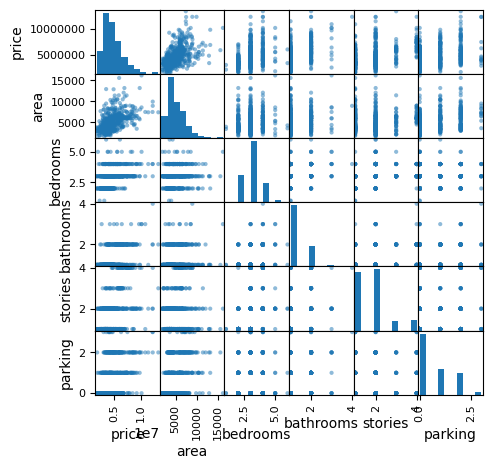

In [636]:
from pandas.plotting import scatter_matrix
p=scatter_matrix(df,figsize=(5,5))

In [637]:
df.corr(numeric_only=True)

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


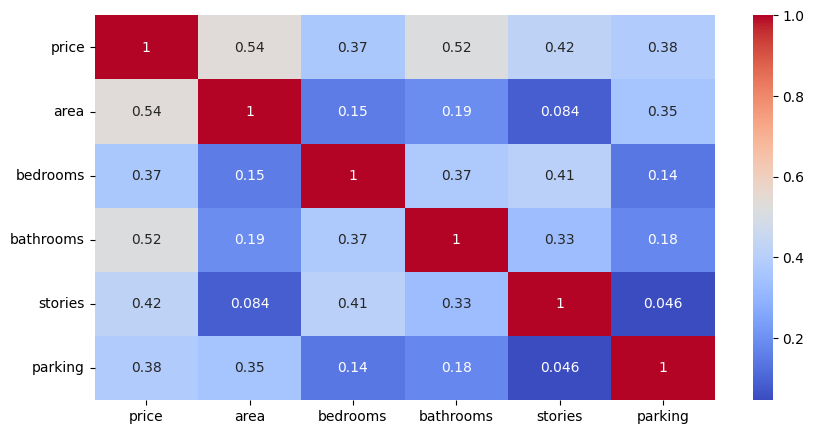

In [638]:
plt.figure(figsize=(10,5))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm")
plt.show()

In [639]:
#df["area"]=np.log1p(df["area"])
# df["price"]=np.log1p(df["price"])

In [640]:
df.head(2)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished


## Feature Engineering

In [641]:
df["area_per_bedrooms"] = df["area"]/df["bedrooms"]

In [642]:
df["area_per_bathroom"] = df["area"] / df["bathrooms"]

In [643]:
df["total_rooms"] = df["bedrooms"] + df["bathrooms"] + df["stories"]

In [644]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus', 'area_per_bedrooms',
       'area_per_bathroom', 'total_rooms'],
      dtype='object')

In [645]:
# df = df.drop(["area", "bedrooms", "bathrooms", "stories"], axis=1)

## Encoding

In [646]:
for i in data_cat.columns:
    print(df[i].value_counts())

mainroad
yes    468
no      77
Name: count, dtype: int64
guestroom
no     448
yes     97
Name: count, dtype: int64
basement
no     354
yes    191
Name: count, dtype: int64
hotwaterheating
no     520
yes     25
Name: count, dtype: int64
airconditioning
no     373
yes    172
Name: count, dtype: int64
prefarea
no     417
yes    128
Name: count, dtype: int64
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


In [647]:
cols = ["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea"]
for i in cols:
    df[i] = df[i].map({'yes':1 , 'no':0})

In [648]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,area_per_bedrooms,area_per_bathroom,total_rooms
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,1855.0,3710.0,9
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,2240.0,2240.0,12
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,3320.0,4980.0,7
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,1875.0,3750.0,8
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,1855.0,7420.0,7


In [649]:
from sklearn.preprocessing import OneHotEncoder
encode = OneHotEncoder(drop='first',sparse_output=False)
encoded = encode.fit_transform(df[['furnishingstatus']])

In [650]:
encoded_df = pd.DataFrame(encoded,
                          columns=encode.get_feature_names_out(['furnishingstatus']))

In [651]:
df = df.drop('furnishingstatus',axis=1)
df= pd.concat([df,encoded_df],axis=1)

In [652]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,area_per_bedrooms,area_per_bathroom,total_rooms,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1855.0,3710.0,9,0.0,0.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2240.0,2240.0,12,0.0,0.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,3320.0,4980.0,7,1.0,0.0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1875.0,3750.0,8,0.0,0.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1855.0,7420.0,7,0.0,0.0


In [653]:
df.shape

(545, 17)

In [654]:
df2 = df.copy()

df2['price'] = np.log1p(df2['price'])


In [655]:
## Data Spliting
X =df2.drop("price",axis=1)
y = df2["price"]

In [656]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [657]:
X_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,area_per_bedrooms,area_per_bathroom,total_rooms,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,6000,3,2,4,1,0,0,0,1,1,0,2000.000000,3000.0,9,0.0,0.0
93,7200,3,2,1,1,0,1,0,1,3,0,2400.000000,3600.0,6,1.0,0.0
335,3816,2,1,1,1,0,1,0,1,2,0,1908.000000,3816.0,4,0.0,0.0
412,2610,3,1,2,1,0,1,0,0,0,1,870.000000,2610.0,6,0.0,1.0
471,3750,3,1,2,1,0,0,0,0,0,0,1250.000000,3750.0,6,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,1,0,0,0,1,0,0,1500.000000,3000.0,10,0.0,1.0
106,5450,4,2,1,1,0,1,0,1,0,1,1362.500000,2725.0,7,1.0,0.0
270,4500,3,2,3,1,0,0,1,0,1,0,1500.000000,2250.0,8,0.0,0.0
435,4040,2,1,1,1,0,0,0,0,0,0,2020.000000,4040.0,4,0.0,1.0


In [658]:
X_test

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,area_per_bedrooms,area_per_bathroom,total_rooms,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,5900,4,2,2,0,0,1,0,0,1,0,1475.000000,2950.0,8,0.0,1.0
77,6500,3,2,3,1,0,0,0,1,0,1,2166.666667,3250.0,8,0.0,0.0
360,4040,2,1,1,1,0,0,0,0,0,0,2020.000000,4040.0,4,1.0,0.0
90,5000,3,1,2,1,0,0,0,1,0,0,1666.666667,5000.0,6,1.0,0.0
493,3960,3,1,1,1,0,0,0,0,0,0,1320.000000,3960.0,5,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,6000,4,1,2,1,0,1,0,0,2,0,1500.000000,6000.0,7,1.0,0.0
357,6930,4,1,2,0,0,0,0,0,1,0,1732.500000,6930.0,7,0.0,0.0
39,6000,4,2,4,1,0,0,0,1,1,0,1500.000000,3000.0,10,1.0,0.0
54,6000,3,2,2,1,1,0,0,1,1,0,2000.000000,3000.0,7,1.0,0.0


In [659]:
y_train

46     15.833742
93     15.656060
335    15.181602
412    15.048071
471    14.917451
         ...    
71     15.725794
106    15.633587
270    15.283385
435    15.006398
102    15.639253
Name: price, Length: 436, dtype: float64

In [660]:
y_test


316    15.216694
77     15.710128
360    15.126543
90     15.678039
493    14.845130
         ...    
15     16.023785
357    15.143381
39     15.883638
54     15.810211
155    15.525699
Name: price, Length: 109, dtype: float64

In [661]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

In [662]:
X_train_scaled

array([[ 0.38416819,  0.05527092,  1.53917323, ...,  1.86501093,
        -0.870669  , -0.67690027],
       [ 0.9291807 ,  0.05527092,  1.53917323, ..., -0.00428738,
         1.14854209, -0.67690027],
       [-0.60775457, -1.28351359, -0.5579503 , ..., -1.25048625,
        -0.870669  , -0.67690027],
       ...,
       [-0.29709744,  0.05527092,  1.53917323, ...,  1.24191149,
        -0.870669  , -0.67690027],
       [-0.5060189 , -1.28351359, -0.5579503 , ..., -1.25048625,
        -0.870669  ,  1.47732249],
       [ 0.15707965,  0.05527092,  1.53917323, ...,  1.86501093,
         1.14854209, -0.67690027]], shape=(436, 16))

### 1.LinearRegression

In [663]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

def evaluate_model(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    return mae, rmse, r2



In [664]:
def print_metrics(model_name,
                  train_mae, train_rmse, train_r2,
                  test_mae, test_rmse, test_r2):

    print("="*40)
    print(model_name)
    print("="*40)

    print("TRAIN PERFORMANCE")
    print(f"MAE  : {train_mae}")
    print(f"RMSE : {train_rmse}")
    print(f"R2   : {train_r2}")

    print("\nTEST PERFORMANCE")
    print(f"MAE  : {test_mae}")
    print(f"RMSE : {test_rmse}")
    print(f"R2   : {test_r2}")

In [665]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1),
    "Lasso": Lasso(alpha=0.01),
    "GradientBoost": GradientBoostingRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(verbose=False, random_state=42),
    "XGB": XGBRegressor(random_state=42)
}

results = []

for name, model in models.items():

    # Linear models -> scaled data
    if name in ["Linear", "Ridge", "Lasso"]:

        model.fit(X_train_scaled, y_train)

        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)

    # Tree models -> original data
    else:

        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

    train_mae, train_rmse, train_r2 = evaluate_model(y_train, train_pred)
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, test_pred)

    print_metrics(
        name,
        train_mae, train_rmse, train_r2,
        test_mae, test_rmse, test_r2
    )

    results.append({
        "Model": name,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Test_MAE": test_mae,
        "Test_RMSE": test_rmse
    })


Linear
TRAIN PERFORMANCE
MAE  : 0.14786615696074545
RMSE : 0.19160115253859397
R2   : 0.7048212958508926

TEST PERFORMANCE
MAE  : 0.2006418440489027
RMSE : 0.25092213912141975
R2   : 0.6739221967427484
Ridge
TRAIN PERFORMANCE
MAE  : 0.1479291850512671
RMSE : 0.19160739453987907
R2   : 0.7048020628156119

TEST PERFORMANCE
MAE  : 0.2005026856730609
RMSE : 0.2510106330606042
R2   : 0.6736921572749732
Lasso
TRAIN PERFORMANCE
MAE  : 0.14843683871395058
RMSE : 0.19344120048260138
R2   : 0.6991245554493504

TEST PERFORMANCE
MAE  : 0.20346044616863823
RMSE : 0.2582235091244383
R2   : 0.6546695843496885
GradientBoost
TRAIN PERFORMANCE
MAE  : 0.09735040817837619
RMSE : 0.12523986299613332
R2   : 0.8738829059764732

TEST PERFORMANCE
MAE  : 0.2051052800006688
RMSE : 0.2602670633386243
R2   : 0.6491821378136527
CatBoost
TRAIN PERFORMANCE
MAE  : 0.05735494099117508
RMSE : 0.07630999887714951
R2   : 0.9531778144331614

TEST PERFORMANCE
MAE  : 0.20026256248366092
RMSE : 0.25752774559688985
R2   : 0.65

In [666]:
results = pd.DataFrame(results)

results.sort_values(
    by="Test_R2",
    ascending=False,
    inplace=True
)

print(results)

           Model  Train_R2   Test_R2  Test_MAE  Test_RMSE
0         Linear  0.704821  0.673922  0.200642   0.250922
1          Ridge  0.704802  0.673692  0.200503   0.251011
4       CatBoost  0.953178  0.656528  0.200263   0.257528
2          Lasso  0.699125  0.654670  0.203460   0.258224
3  GradientBoost  0.873883  0.649182  0.205105   0.260267
5            XGB  0.994000  0.574000  0.227229   0.286803


In [667]:
best_model = LinearRegression()
best_model.fit(X_train_scaled, y_train)

LinearRegression()

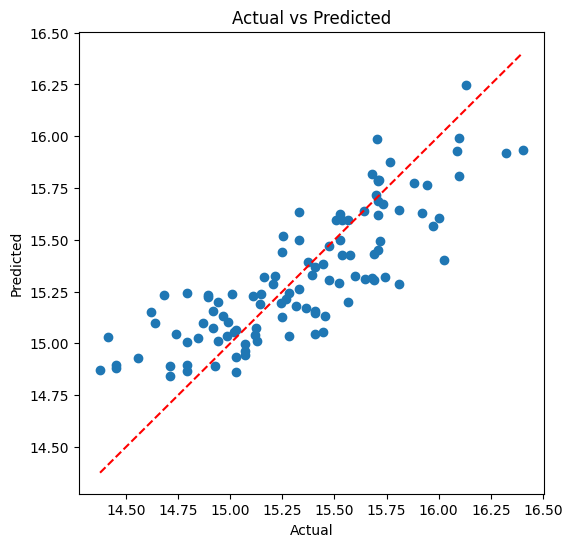

In [668]:
y_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

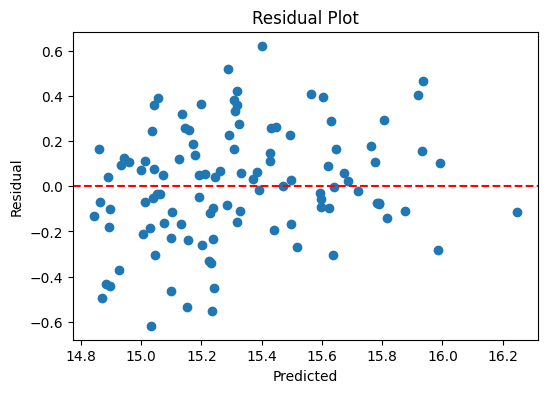

In [669]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [670]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    LinearRegression(),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("Fold Scores:", scores)
print("Average R2:", scores.mean())

Fold Scores: [0.69643304 0.69514712 0.66566945 0.68342023 0.6423099 ]
Average R2: 0.6765959461122054


In [671]:
new_house = pd.DataFrame({
    "area":[7500],
    "bedrooms":[3],
    "bathrooms":[2],
    "stories":[2],
    "mainroad":[1],
    "guestroom":[0],
    "basement":[0],
    "hotwaterheating":[0],
    "airconditioning":[1],
    "parking":[2],
    "prefarea":[1],
    "area_per_bedrooms":[7500/3],
    "area_per_bathroom":[7500/2],
    "total_rooms":[3+2+2],
    "furnishingstatus_semi-furnished":[1],
    "furnishingstatus_unfurnished":[0]
})

new_scaled = ss.transform(new_house)

pred = best_model.predict(new_scaled)

print("Log Price:", pred[0])
print("Actual Price:", np.expm1(pred[0]))

Log Price: 15.840215048788036
Actual Price: 7573871.465094416
